In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("UPI Monthly Product Statistics Trended.csv")

In [3]:
df.head()

,Month,Volume (in Mn.),Avg. Daily Volume (in Mn.)
0,24-Jan,"12,203.02",393.65
1,24-Feb,"12,102.67",417.33
2,24-Mar,"13,440.00",433.55
3,24-Apr,"13,303.99",443.47
4,24-May,"14,035.84",452.77


In [4]:
df.columns

Index(['Month', 'Volume (in Mn.)', 'Avg. Daily Volume (in Mn.)'], dtype='object')

In [5]:
df = df.rename(columns={
    'Month': 'Date',
    'Volume (in Mn.)': 'Volume_Mn',
    'Avg. Daily Volume (in Mn.)': 'Avg_Daily_Volume_Mn'
})

df.head()

,Date,Volume_Mn,Avg_Daily_Volume_Mn
0,24-Jan,"12,203.02",393.65
1,24-Feb,"12,102.67",417.33
2,24-Mar,"13,440.00",433.55
3,24-Apr,"13,303.99",443.47
4,24-May,"14,035.84",452.77


In [7]:
df['Date'].unique()

array(['24-Jan', '24-Feb', '24-Mar', '24-Apr', '24-May', '24-Jun',
       '24-Jul', '24-Aug', '24-Sep', '24-Oct', '24-Nov', '24-Dec'],
      dtype=object)

In [8]:
df['Date'] = pd.to_datetime(df['Date'], format='%y-%b')
df.head()

,Date,Volume_Mn,Avg_Daily_Volume_Mn
0,2024-01-01,"12,203.02",393.65
1,2024-02-01,"12,102.67",417.33
2,2024-03-01,"13,440.00",433.55
3,2024-04-01,"13,303.99",443.47
4,2024-05-01,"14,035.84",452.77


In [9]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

df.head()

,Date,Volume_Mn,Avg_Daily_Volume_Mn,Year,Month
0,2024-01-01,"12,203.02",393.65,2024,1
1,2024-02-01,"12,102.67",417.33,2024,2
2,2024-03-01,"13,440.00",433.55,2024,3
3,2024-04-01,"13,303.99",443.47,2024,4
4,2024-05-01,"14,035.84",452.77,2024,5


In [10]:
df = df.sort_values(by='Date')
df

,Date,Volume_Mn,Avg_Daily_Volume_Mn,Year,Month
0,2024-01-01,"12,203.02",393.65,2024,1
1,2024-02-01,"12,102.67",417.33,2024,2
2,2024-03-01,"13,440.00",433.55,2024,3
3,2024-04-01,"13,303.99",443.47,2024,4
4,2024-05-01,"14,035.84",452.77,2024,5
5,2024-06-01,"13,885.14",462.84,2024,6
6,2024-07-01,"14,435.55",465.66,2024,7
7,2024-08-01,"14,963.05",482.68,2024,8
8,2024-09-01,"15,041.75",501.39,2024,9
9,2024-10-01,"16,584.97",535.00,2024,10


In [12]:
df.head()

,Date,Volume_Mn,Avg_Daily_Volume_Mn,Year,Month
0,2024-01-01,"12,203.02",393.65,2024,1
1,2024-02-01,"12,102.67",417.33,2024,2
2,2024-03-01,"13,440.00",433.55,2024,3
3,2024-04-01,"13,303.99",443.47,2024,4
4,2024-05-01,"14,035.84",452.77,2024,5


In [13]:
df['Volume_Mn'] = df['Volume_Mn'].str.replace(',', '').astype(float)
df['Avg_Daily_Volume_Mn'] = df['Avg_Daily_Volume_Mn'].astype(float)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 12 non-null     datetime64[ns]
 1   Volume_Mn            12 non-null     float64       
 2   Avg_Daily_Volume_Mn  12 non-null     float64       
 3   Year                 12 non-null     int32         
 4   Month                12 non-null     int32         
dtypes: datetime64[ns](1), float64(2), int32(2)
memory usage: 516.0 bytes


In [14]:
df['Growth_%'] = df['Volume_Mn'].pct_change() * 100

df.head()

,Date,Volume_Mn,Avg_Daily_Volume_Mn,Year,Month,Growth_%
0,2024-01-01,12203.02,393.65,2024,1,NaN
1,2024-02-01,12102.67,417.33,2024,2,-0.822337
2,2024-03-01,13440.00,433.55,2024,3,11.049876
3,2024-04-01,13303.99,443.47,2024,4,-1.011979
4,2024-05-01,14035.84,452.77,2024,5,5.500981


In [15]:
df[['Date', 'Volume_Mn', 'Growth_%']]

,Date,Volume_Mn,Growth_%
0,2024-01-01,12203.02,NaN
1,2024-02-01,12102.67,-0.822337
2,2024-03-01,13440.00,11.049876
3,2024-04-01,13303.99,-1.011979
4,2024-05-01,14035.84,5.500981
5,2024-06-01,13885.14,-1.073680
6,2024-07-01,14435.55,3.964022
7,2024-08-01,14963.05,3.654173
8,2024-09-01,15041.75,0.525962
9,2024-10-01,16584.97,10.259578


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 12 non-null     datetime64[ns]
 1   Volume_Mn            12 non-null     float64       
 2   Avg_Daily_Volume_Mn  12 non-null     float64       
 3   Year                 12 non-null     int32         
 4   Month                12 non-null     int32         
 5   Growth_%             11 non-null     float64       
dtypes: datetime64[ns](1), float64(3), int32(2)
memory usage: 612.0 bytes


In [17]:
df.head()

,Date,Volume_Mn,Avg_Daily_Volume_Mn,Year,Month,Growth_%
0,2024-01-01,12203.02,393.65,2024,1,NaN
1,2024-02-01,12102.67,417.33,2024,2,-0.822337
2,2024-03-01,13440.00,433.55,2024,3,11.049876
3,2024-04-01,13303.99,443.47,2024,4,-1.011979
4,2024-05-01,14035.84,452.77,2024,5,5.500981


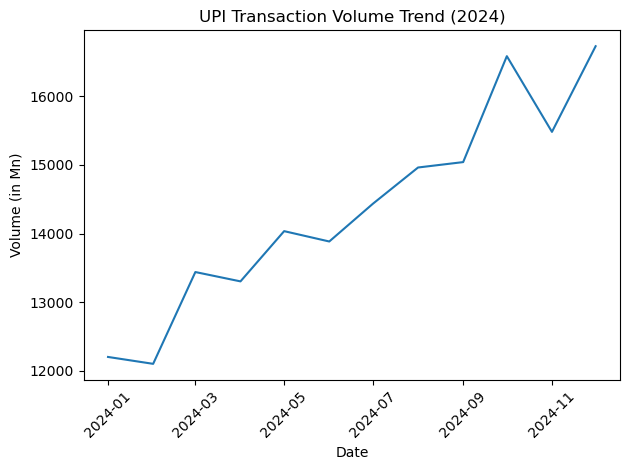

In [18]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df['Date'], df['Volume_Mn'])

plt.title("UPI Transaction Volume Trend (2024)")
plt.xlabel("Date")
plt.ylabel("Volume (in Mn)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

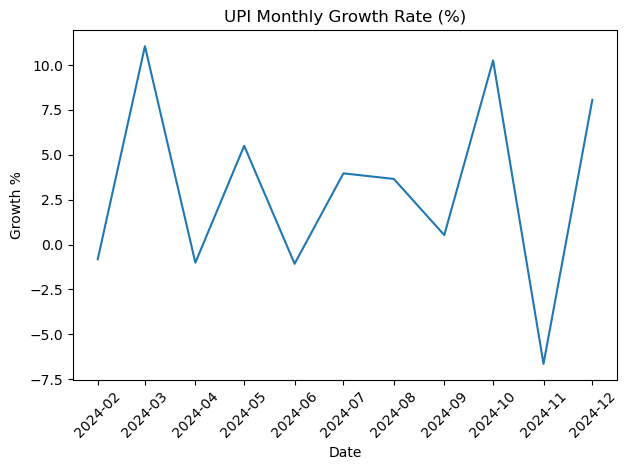

In [19]:
plt.figure()
plt.plot(df['Date'], df['Growth_%'])

plt.title("UPI Monthly Growth Rate (%)")
plt.xlabel("Date")
plt.ylabel("Growth %")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [20]:
df_imps = pd.read_csv("IMPS Monthly Product Statistics Trended.csv")

df_imps.head()

,Month,Volume (in Mn.),Avg. Daily Volume (in Mn.)
0,24-Jan,508.79,16.41
1,24-Feb,534.64,18.44
2,24-Mar,580.64,18.73
3,24-Apr,550.37,18.35
4,24-May,557.70,17.99


In [22]:
df_imps = df_imps.rename(columns={
    'Month': 'Date',
    'Volume (in Mn.)': 'Volume_Mn',
    'Avg. Daily Volume (in Mn.)': 'Avg_Daily_Volume_Mn'
})

df_imps['Date'] = pd.to_datetime(df_imps['Date'], format='%y-%b')

df_imps['Volume_Mn'] = df_imps['Volume_Mn'].astype(float)
df_imps['Avg_Daily_Volume_Mn'] = df_imps['Avg_Daily_Volume_Mn'].astype(float)

df_imps['Payment_Type'] = 'IMPS'

df_imps.head()

,Date,Volume_Mn,Avg_Daily_Volume_Mn,Payment_Type
0,2024-01-01,508.79,16.41,IMPS
1,2024-02-01,534.64,18.44,IMPS
2,2024-03-01,580.64,18.73,IMPS
3,2024-04-01,550.37,18.35,IMPS
4,2024-05-01,557.70,17.99,IMPS


In [23]:
df_imps.head()

,Date,Volume_Mn,Avg_Daily_Volume_Mn,Payment_Type
0,2024-01-01,508.79,16.41,IMPS
1,2024-02-01,534.64,18.44,IMPS
2,2024-03-01,580.64,18.73,IMPS
3,2024-04-01,550.37,18.35,IMPS
4,2024-05-01,557.70,17.99,IMPS


In [24]:
df['Payment_Type'] = 'UPI'
df_combined = pd.concat([df, df_imps])
df_combined['Payment_Type'].value_counts()

Payment_Type
UPI     12
IMPS    12
Name: count, dtype: int64

In [25]:
df_combined.groupby('Payment_Type')['Volume_Mn'].sum()

Payment_Type
IMPS      5938.35
UPI     172208.01
Name: Volume_Mn, dtype: float64

In [26]:
pivot_df = df_combined.pivot(index='Date', columns='Payment_Type', values='Volume_Mn')

pivot_df

Payment_Type,IMPS,UPI
Date,,
2024-01-01,508.79,12203.02
2024-02-01,534.64,12102.67
2024-03-01,580.64,13440.00
2024-04-01,550.37,13303.99
2024-05-01,557.70,14035.84
2024-06-01,516.75,13885.14
2024-07-01,490.28,14435.55
2024-08-01,453.34,14963.05
2024-09-01,429.94,15041.75


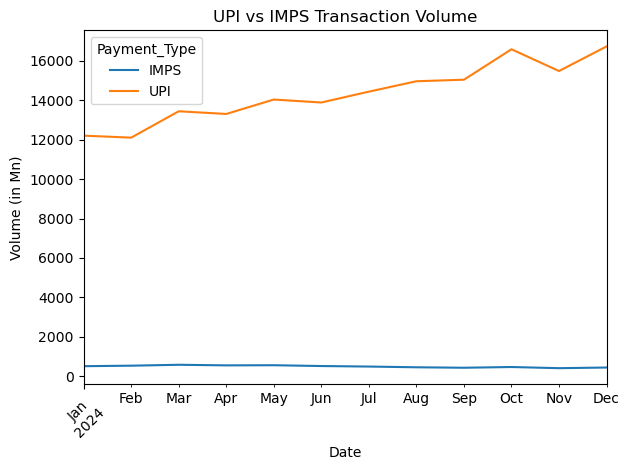

In [27]:
import matplotlib.pyplot as plt

pivot_df.plot()

plt.title("UPI vs IMPS Transaction Volume")
plt.xlabel("Date")
plt.ylabel("Volume (in Mn)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [28]:
df_aeps = pd.read_csv("AePS - Cash Withdrawal Monthly Product Statistics Trended.csv")

df_aeps.head()

,Month,Volume (in Mn.),Avg. Daily Volume (in Mn.)
0,24-Jan,83.97,2.71
1,24-Feb,81.22,2.80
2,24-Mar,105.96,3.42
3,24-Apr,91.91,3.06
4,24-May,87.98,2.84


In [29]:
df_aeps = df_aeps.rename(columns={
    'Month': 'Date',
    'Volume (in Mn.)': 'Volume_Mn',
    'Avg. Daily Volume (in Mn.)': 'Avg_Daily_Volume_Mn'
})

df_aeps['Date'] = pd.to_datetime(df_aeps['Date'], format='%y-%b')

# Handle both cases (string or numeric)
df_aeps['Volume_Mn'] = df_aeps['Volume_Mn'].astype(str).str.replace(',', '').astype(float)
df_aeps['Avg_Daily_Volume_Mn'] = df_aeps['Avg_Daily_Volume_Mn'].astype(float)

df_aeps['Payment_Type'] = 'AePS_Cash'

df_aeps.head()

,Date,Volume_Mn,Avg_Daily_Volume_Mn,Payment_Type
0,2024-01-01,83.97,2.71,AePS_Cash
1,2024-02-01,81.22,2.80,AePS_Cash
2,2024-03-01,105.96,3.42,AePS_Cash
3,2024-04-01,91.91,3.06,AePS_Cash
4,2024-05-01,87.98,2.84,AePS_Cash


In [30]:
df_combined = pd.concat([df_combined, df_aeps])

df_combined['Payment_Type'].value_counts()

Payment_Type
UPI          12
IMPS         12
AePS_Cash    12
Name: count, dtype: int64

In [31]:
def load_and_clean(file_name, payment_name):
    df_temp = pd.read_csv(file_name)
    
    df_temp = df_temp.rename(columns={
        'Month': 'Date',
        'Volume (in Mn.)': 'Volume_Mn',
        'Avg. Daily Volume (in Mn.)': 'Avg_Daily_Volume_Mn'
    })
    
    df_temp['Date'] = pd.to_datetime(df_temp['Date'], format='%y-%b')
    
    # Handle both string & numeric cases
    df_temp['Volume_Mn'] = df_temp['Volume_Mn'].astype(str).str.replace(',', '').astype(float)
    df_temp['Avg_Daily_Volume_Mn'] = df_temp['Avg_Daily_Volume_Mn'].astype(float)
    
    df_temp['Payment_Type'] = payment_name
    
    return df_temp

In [32]:
df_nach_credit = load_and_clean("NACH - Credit Monthly Product Statistics Trended.csv", "NACH_Credit")

df_nach_debit = load_and_clean("NACH - Debit Monthly Product Statistics Trended.csv", "NACH_Debit")

df_nach_apbs = load_and_clean("NACH - APBS Monthly Product Statistics Trended.csv", "NACH_APBS")

df_netc = load_and_clean("NETC Monthly Product Statistics Trended.csv", "NETC")

df_aeps_fund = load_and_clean("AePS - Funds Transfer Monthly Product Statistics Trended.csv", "AePS_Fund")

In [33]:
df_combined = pd.concat([
    df_combined,
    df_nach_credit,
    df_nach_debit,
    df_nach_apbs,
    df_netc,
    df_aeps_fund
])

df_combined['Payment_Type'].value_counts()

Payment_Type
UPI            12
IMPS           12
AePS_Cash      12
NACH_Credit    12
NACH_Debit     12
NACH_APBS      12
NETC           12
AePS_Fund      12
Name: count, dtype: int64

In [34]:
top_payment = df_combined.groupby('Payment_Type')['Volume_Mn'].sum().sort_values(ascending=False)

top_payment

Payment_Type
UPI            172208.01
IMPS             5938.35
NETC             4059.33
NACH_APBS        3219.05
NACH_Credit      1650.14
AePS_Cash        1141.31
NACH_Debit        625.94
AePS_Fund           0.37
Name: Volume_Mn, dtype: float64

In [35]:
top_payment.head(1)

Payment_Type
UPI    172208.01
Name: Volume_Mn, dtype: float64

In [36]:
market_share = (top_payment / top_payment.sum()) * 100

market_share

Payment_Type
UPI            91.191342
IMPS            3.144605
NETC            2.149585
NACH_APBS       1.704622
NACH_Credit     0.873818
AePS_Cash       0.604371
NACH_Debit      0.331461
AePS_Fund       0.000196
Name: Volume_Mn, dtype: float64

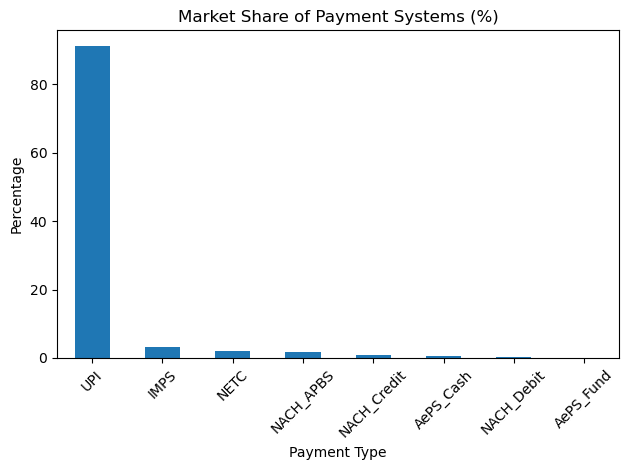

In [37]:
import matplotlib.pyplot as plt

market_share.plot(kind='bar')

plt.title("Market Share of Payment Systems (%)")
plt.xlabel("Payment Type")
plt.ylabel("Percentage")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [38]:
!pip install psycopg2-binary sqlalchemy

In [39]:
from sqlalchemy import create_engine

username = "postgres"
password = "sk123"
host = "localhost"
port = "5432"
database = "payments_db"

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

In [40]:
df_combined.to_sql('payments', engine, if_exists='replace', index=False)

96